In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('optimal_ranges_combo.csv')

df = df.set_index("Unnamed: 0")

labels = df.columns.tolist()
df = df.loc[labels, labels]  

data = df.fillna("").values.tolist()

In [17]:
def get_range_width(cell):
    try:
        nums = eval(cell)
        return nums[1] - nums[0]
    except:
        return np.nan

In [18]:
value_matrix = np.array([
    [get_range_width(cell) for cell in row]
    for row in data
])

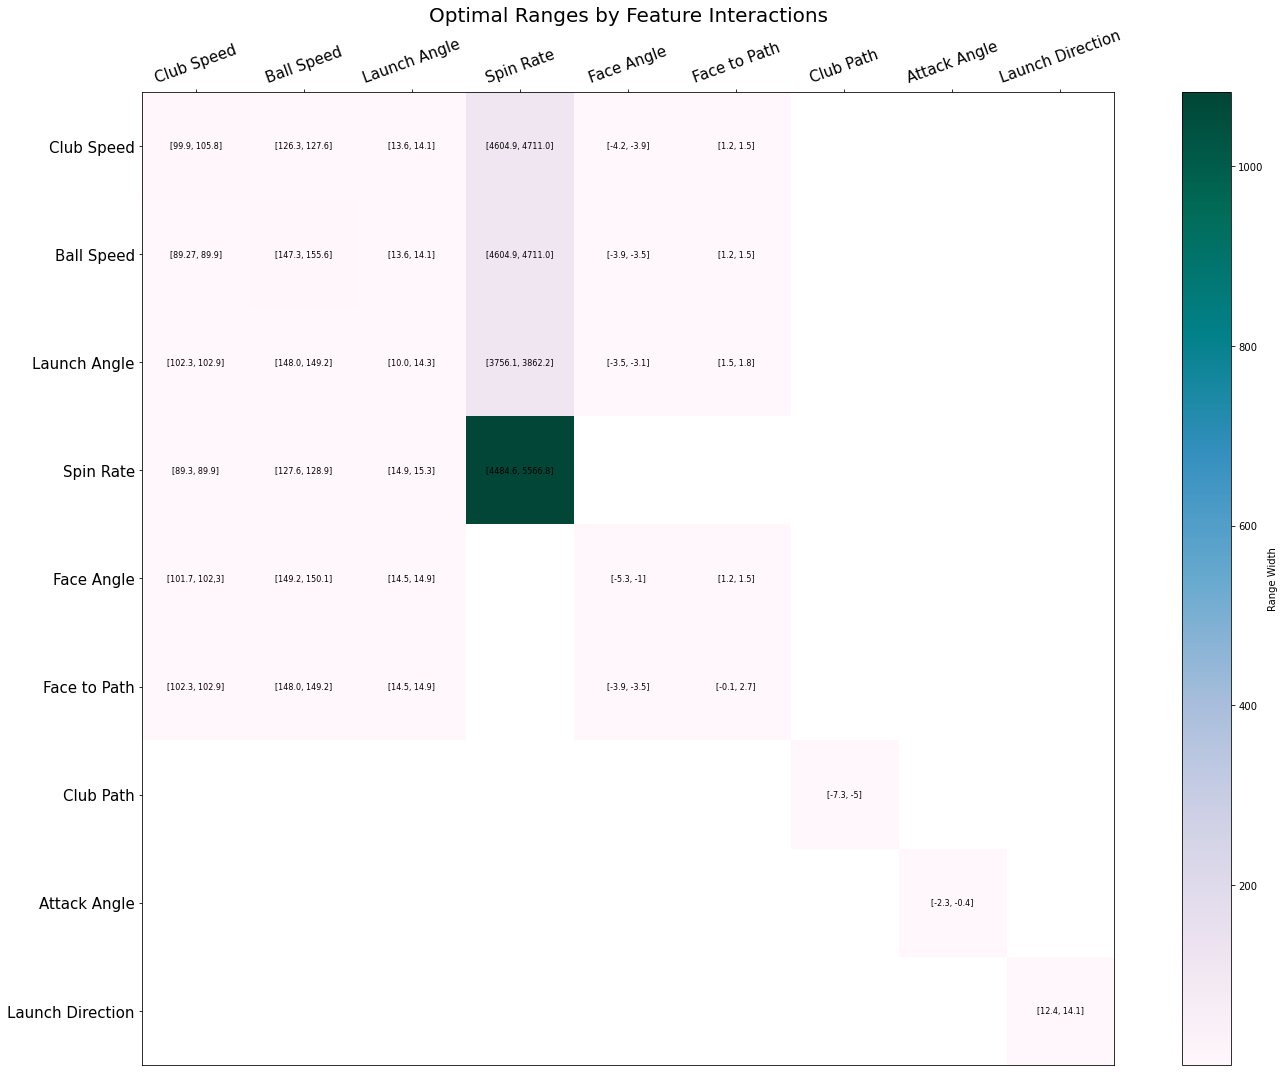

In [50]:
fig, ax = plt.subplots(figsize=(20, 15))
masked_array = np.ma.masked_invalid(value_matrix)
cmap.set_bad(color='white')  # Make NaNs white

c = ax.imshow(masked_array, cmap='PuBuGn')

for i in range(len(labels)):
    for j in range(len(labels)):
        if data[i][j] != "":
            ax.text(j, i, data[i][j], ha='center', va='center', fontsize=8)

ax.set_xticks(np.arange(len(labels)))
ax.xaxis.tick_top()
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, fontsize=15, rotation = 20)
ax.set_yticklabels(labels, fontsize=15)
plt.title("Optimal Ranges by Feature Interactions", fontsize=20)

cbar = fig.colorbar(c, ax=ax, label="Range Width")
plt.tight_layout()
plt.show()